In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
data = pd.read_csv("../../Data.csv")
data = data.drop(columns=["VD", "VE", "tempo"])
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data = data.rename(columns={
    "Setpoint VD": "Wd",
    "Setpoint VE": "We",
    "Theta": "theta(Wd,We)",
    "X": "x(Wd,We)",
    "Y": "y(Wd,We)",
})

In [11]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Estilo Seaborn
    sns.set_theme(style="whitegrid")

    # Criando a figura
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotando Wd e We como linhas
    for preds in PREDICTORS:
        sns.lineplot(x=df.index, y=df[preds], ax=ax1, marker="o", label=preds,  linewidth=2)

    if PlotOut:
        ax2 = ax1.twinx()
        for target in TARGET:
            sns.lineplot(x=df.index, y=df[target], ax=ax2, marker="o", label=target, linestyle="dashed", linewidth=2, color="red")
            ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")

    # Ajustando os rótulos dos eixos
    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")

    # Adicionando legendas
    ax1.legend(loc="upper left")
    if PlotOut:
        ax2.legend(loc="upper right")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)

    # Exibindo o gráfico
    plt.show()

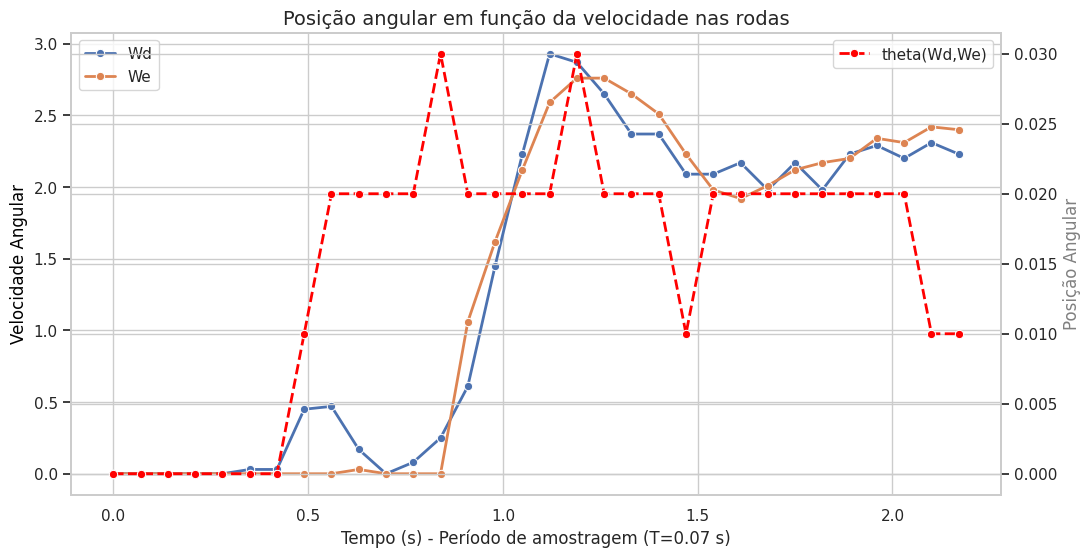

In [12]:
PlotTimeSeries(data.head(32))

In [13]:
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

def get_XY(data, time_steps, units, output_dim):
    total_samples = (len(data) - time_steps) // time_steps

    X = []
    Y = []
    
    for i in range(total_samples):
        start_idx = i * time_steps
        end_idx = start_idx + time_steps

        X_seq = data.iloc[start_idx:end_idx][PREDICTORS].values  # shape: (time_steps, features)
        Y_target = data.iloc[end_idx][TARGET]  # escalar

        X.append(X_seq)
        Y.append(Y_target)

    X = np.array(X)  # shape: (batch, time_steps, features)
    Y =  Y = np.array(Y).reshape(-1, 1).repeat(output_dim, axis=1)  # shape (batch, output_dim)
    h0 = np.full((X.shape[0], units), fill_value=Y[0]) # shape (batch, units)

    print(f"Shape X (batch, time_steps, features): {X.shape}")
    print(f"Shape Y (batch, output_dim): {Y.shape}")
    print(f"Shape h0 (batch, units): {h0.shape}")
    
    return X, Y, h0

In [14]:
def PlotOut(valuer):
    sns.set_theme(style="whitegrid")

    fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharey=False)

    datasets = [
        ('Treinamento', valuer.train_samples_y, valuer.train_pred),
        ('Validação', valuer.val_samples_y, valuer.val_pred),
        ('Teste', valuer.test_samples_y, valuer.test_pred)
    ]

    times = [
        np.arange(len(valuer.train_samples_y)),
        np.arange(len(valuer.val_samples_y)),
        np.arange(len(valuer.test_samples_y))
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        # Garante que são vetores 1D
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)

        sns.lineplot(x=times[i], y=y_true, ax=axs[i], marker="o", label="Amostras Reais", linewidth=2)
        sns.lineplot(x=times[i], y=y_pred, ax=axs[i], marker="o", label="Valores preditos", linewidth=2)

        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Tempo')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação temporal: Predição (curva) vs Amostras Reais (pontos)')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()  
    
    path = f"./content/models/{valuer.fileName}.png"
    fig.savefig(path)    

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from keras import layers, models, regularizers, initializers, optimizers
from keras.callbacks import EarlyStopping
from itertools import product


class EvalRNN:
    
    def __init__(self, dataset, epochs, time_steps, act_h, act_o):
        self.epochs = epochs
        self.Dataset = dataset
        self.output_dim = np.size(TARGET)
        self.time_steps = time_steps
        self.act_h = act_h
        self.act_o = act_o
        self.better_metrics = {}


    def SplitData(self, units):
        self.units = units
                
        train_data, test_data = train_test_split(self.Dataset, test_size=0.25, shuffle=False)
        train_data, val_data = train_test_split(train_data, test_size=0.15, shuffle=False)
                
        self.train_samples_x, self.train_samples_y, self.h0_train = get_XY(train_data, self.time_steps, units, self.output_dim)       
        self.val_samples_x, self.val_samples_y, self.h0_val = get_XY(val_data, self.time_steps, units, self.output_dim)
        self.test_samples_x, self.test_samples_y, self.h0_test = get_XY(test_data, self.time_steps, units, self.output_dim)

        self.time_steps = self.train_samples_x.shape[1]
        self.features = self.train_samples_x.shape[2]
        
    def BuildModel(self, hidden_sizes, param_reg):
        initializer = initializers.RandomUniform(minval=-0.5,
                                                maxval=0.5,
                                                # seed=np.random.randint(1, 10000)
                                                )
        regularizer = regularizers.L2(param_reg)
        inputs = layers.Input((self.time_steps, self.features))
        initial_state = layers.Input((self.units,))

        # Primeira camada RNN com estado inicial
        rnn_layer = layers.SimpleRNN(
            hidden_sizes[0],
            activation=self.act_h,
            kernel_regularizer=regularizer,
            kernel_initializer=initializer,
            return_sequences=(len(hidden_sizes) > 1)  
        )(inputs, initial_state=initial_state)

        # Demais camadas RNN
        for size in hidden_sizes[1:-1]:
            rnn_layer = layers.SimpleRNN(
                size,
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=True 
            )(rnn_layer)

        # Última camada RNN
        if len(hidden_sizes) > 1:
            rnn_layer = layers.SimpleRNN(
                hidden_sizes[-1],
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=False  
            )(rnn_layer)
       
       # Output mlp layer
        output = layers.Dense(self.output_dim,
                            activation=self.act_o,
                            kernel_regularizer=regularizer,
                            kernel_initializer=initializer)(rnn_layer)
        
        model = models.Model([inputs] + [initial_state], output)
        return(model)
    
    def CompileModel(self, model, lr):
        model.compile(loss="mse", optimizer=optimizers.Adam(learning_rate=lr))
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        model.fit(
            [self.train_samples_x, self.h0_train],
            self.train_samples_y,
            epochs=self.epochs,
            validation_data=([self.val_samples_x, self.h0_val], self.val_samples_y),
            callbacks=[early_stop],
            verbose=False,
            shuffle=False   
        )
    
    def ComputeMetrics(self, model):
        self.train_pred = np.squeeze(model.predict([self.train_samples_x, self.h0_train]))
        self.val_pred = np.squeeze(model.predict([self.val_samples_x, self.h0_val]))
        self.test_pred = np.squeeze(model.predict([self.test_samples_x, self.h0_test]))


        return ({
                    'r2_training': r2_score(self.train_samples_y, self.train_pred),
                    'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
                    'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
                    'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

                    'r2_test': r2_score(self.test_samples_y, self.test_pred),
                    'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
                    'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
                    'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
                    
                    'r2_val': r2_score(self.val_samples_y, self.val_pred),
                    'mse_val': mean_squared_error(self.val_samples_y, self.val_pred),
                    'mape_val': mean_absolute_percentage_error(self.val_samples_y, self.val_pred),
                    'rmse_val': root_mean_squared_error(self.val_samples_y, self.val_pred),
            })

    def SaveModelWeights(self, model):
        path = f"./content/models/{self.fileName}.weights.h5"
        open(path,'w').close()
        model.save_weights(path) 

    def LoopWeights(self, model, run_times, lr, boundarie, sort_by, idx):
        better_model = 0
        save = False

        for i in range(run_times):
            print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
            self.CompileModel(model, lr)
            metrics = self.ComputeMetrics(model)
            
            if (metrics[sort_by] >= boundarie): # should be >= to acsending metrics
                self.fileName = f"model_{idx}_{better_model}"
                self.SaveModelWeights(model)
                self.better_metrics[self.fileName] = metrics
                better_model += 1
                save = True
                PlotOut(self)

        return(save)

    def Evaluate(self, hidden_sizes, regularizers, learning_rate, run_times, boundarie, sort_by):
        for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
            header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
            print(f"Testando combinacao{count}: {header}")
            
            self.SplitData(units=hidden_size[0])        
            model = self.BuildModel(hidden_size, reg)
            
            if (self.LoopWeights(model, run_times, lr, boundarie, sort_by, f"{count}") == True):        
                self.DisplayBetterResults(header, sort_by, f"{count}")
                
        self.better_metrics = {}
  
                
    def DisplayBetterResults(self, header, sort_by, dataset=0):
        df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
        df = df.sort_values([sort_by])
        display(df)
        path = f'./content/results/metrics_{dataset}'
        df.to_excel(f"{path}.xlsx", index=True)
        print(f"DataFrame salvo em {path}")
        with open(f"{path}.txt", 'w') as arquivo:
            arquivo.write(header)            
       

In [16]:
Valuer = EvalRNN(dataset = data,
                epochs = 5000,
                time_steps = 10,
                act_h = 'tanh',
                act_o = 'sigmoid',
                )        

Testando combinacao1: Hidden Size=[30], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (135, 10, 2)
Shape Y (batch, output_dim): (135, 1)
Shape h0 (batch, units): (135, 30)
Shape X (batch, time_steps, features): (23, 10, 2)
Shape Y (batch, output_dim): (23, 1)
Shape h0 (batch, units): (23, 30)
Shape X (batch, time_steps, features): (52, 10, 2)
Shape Y (batch, output_dim): (52, 1)
Shape h0 (batch, units): (52, 30)
+++++++++++ [1] | 1 ++++++++++++++++++


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
+++++++++++ [1] | 2 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


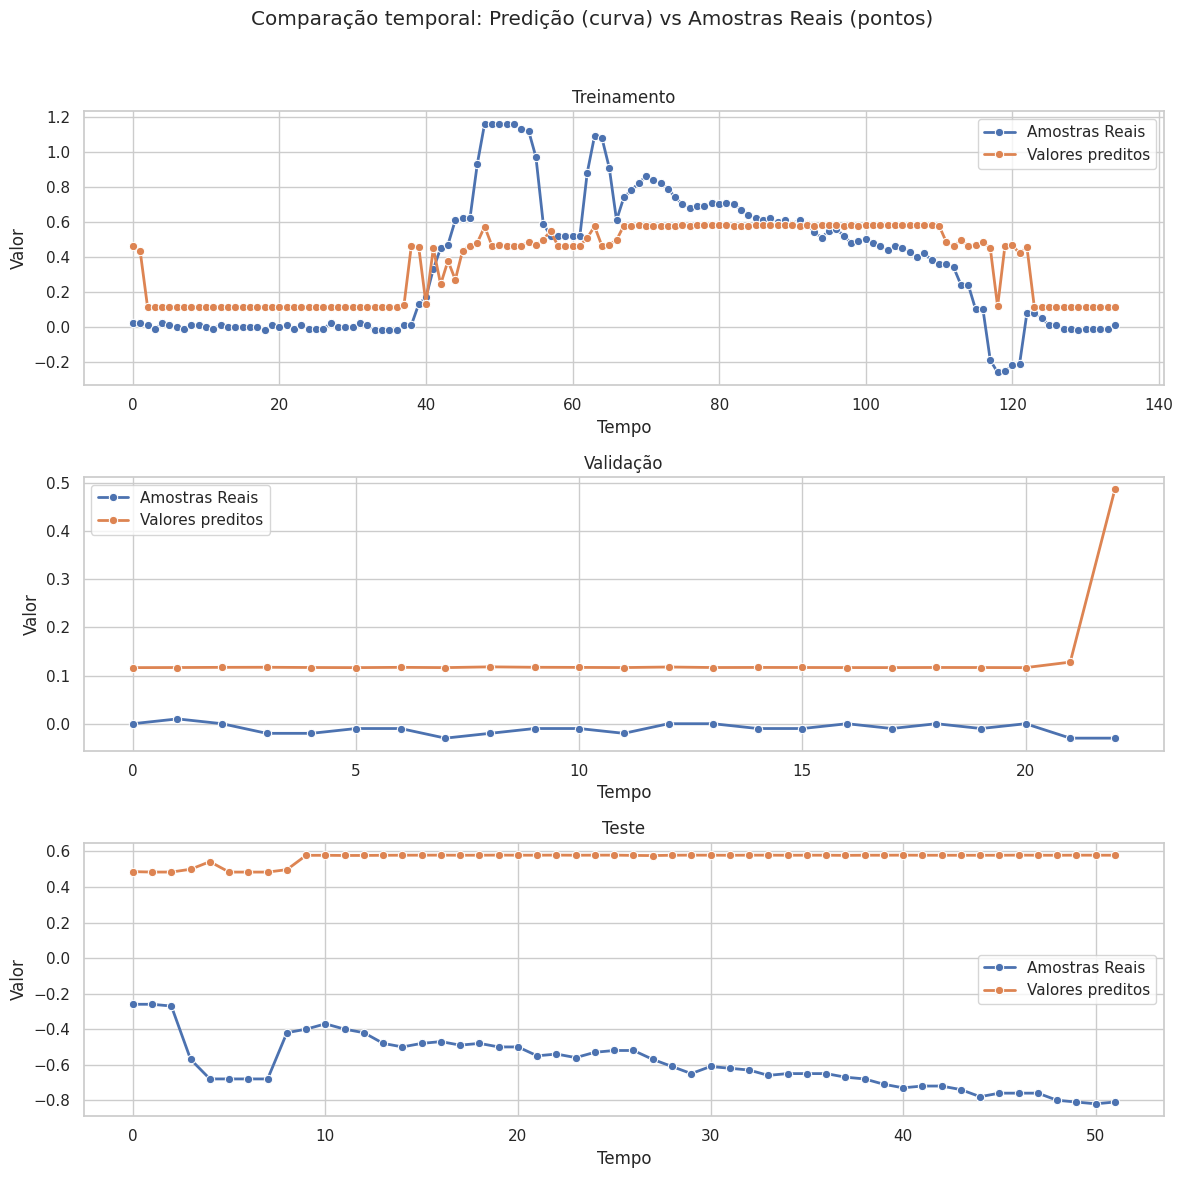

+++++++++++ [1] | 3 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
+++++++++++ [1] | 4 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
+++++++++++ [1] | 5 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
+++++++++++ [1] | 6 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
+++++++++++ [1] | 7 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
+++++++++++ [1] | 8 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
+++++++++++ [1] | 9 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━

,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_1_0,0.504771,0.0702,4.257583e+13,0.264954,-64.578358,1.360761,2.021356,1.166516,-230.927064,0.027182,1.602985e+14,0.164871


DataFrame salvo em ./content/results/metrics_1
Testando combinacao2: Hidden Size=[35], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (135, 10, 2)
Shape Y (batch, output_dim): (135, 1)
Shape h0 (batch, units): (135, 35)
Shape X (batch, time_steps, features): (23, 10, 2)
Shape Y (batch, output_dim): (23, 1)
Shape h0 (batch, units): (23, 35)
Shape X (batch, time_steps, features): (52, 10, 2)
Shape Y (batch, output_dim): (52, 1)
Shape h0 (batch, units): (52, 35)
+++++++++++ [2] | 1 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


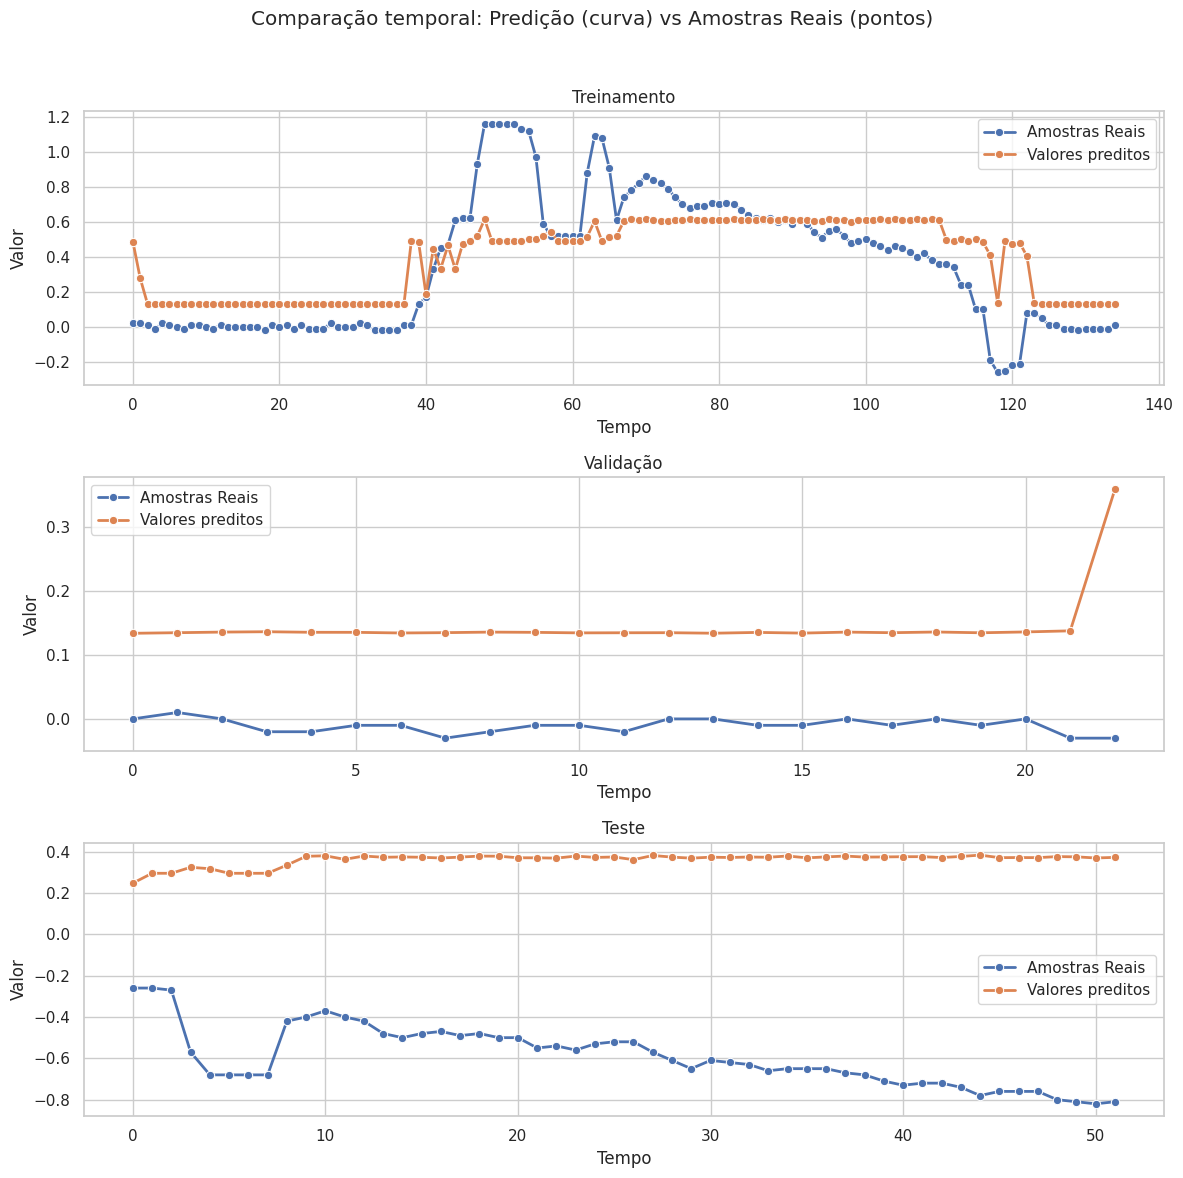

+++++++++++ [2] | 2 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


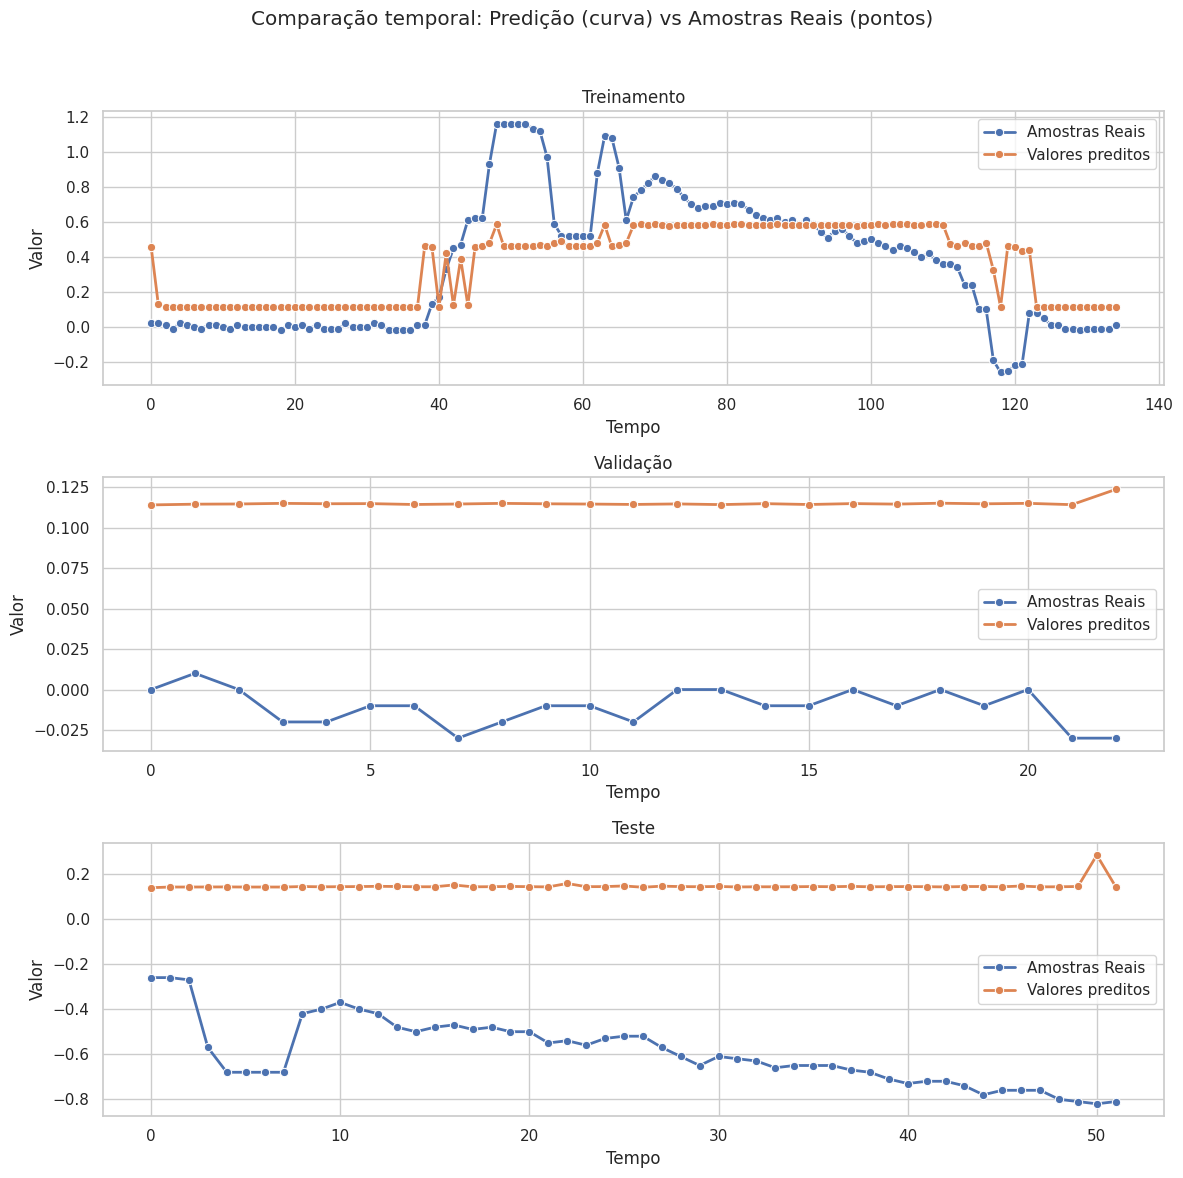

+++++++++++ [2] | 3 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
+++++++++++ [2] | 4 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


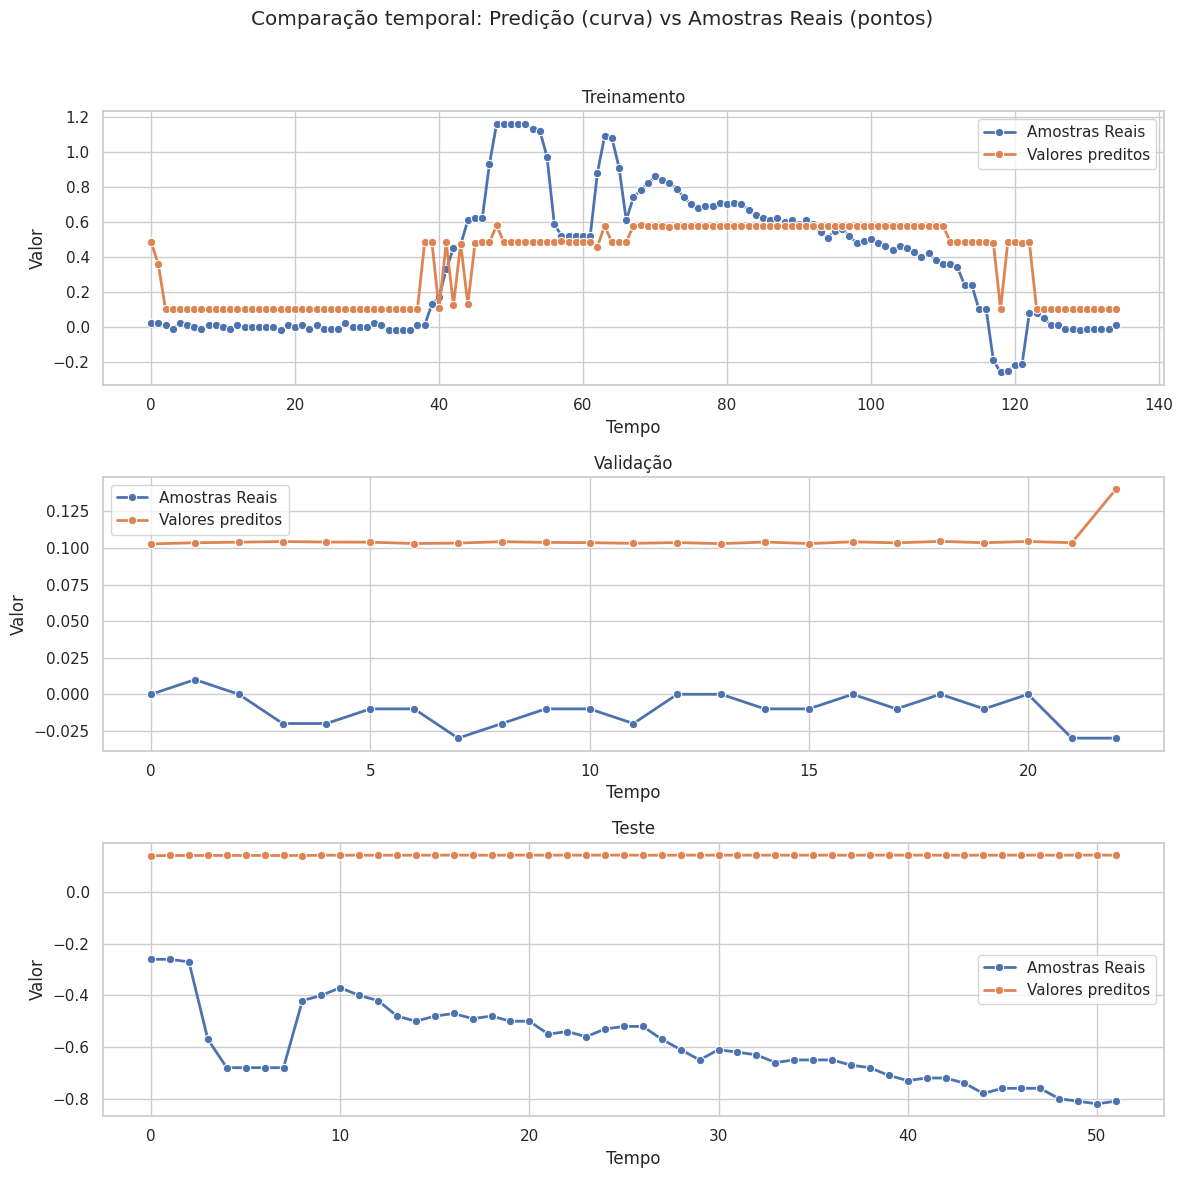

+++++++++++ [2] | 5 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
+++++++++++ [2] | 6 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


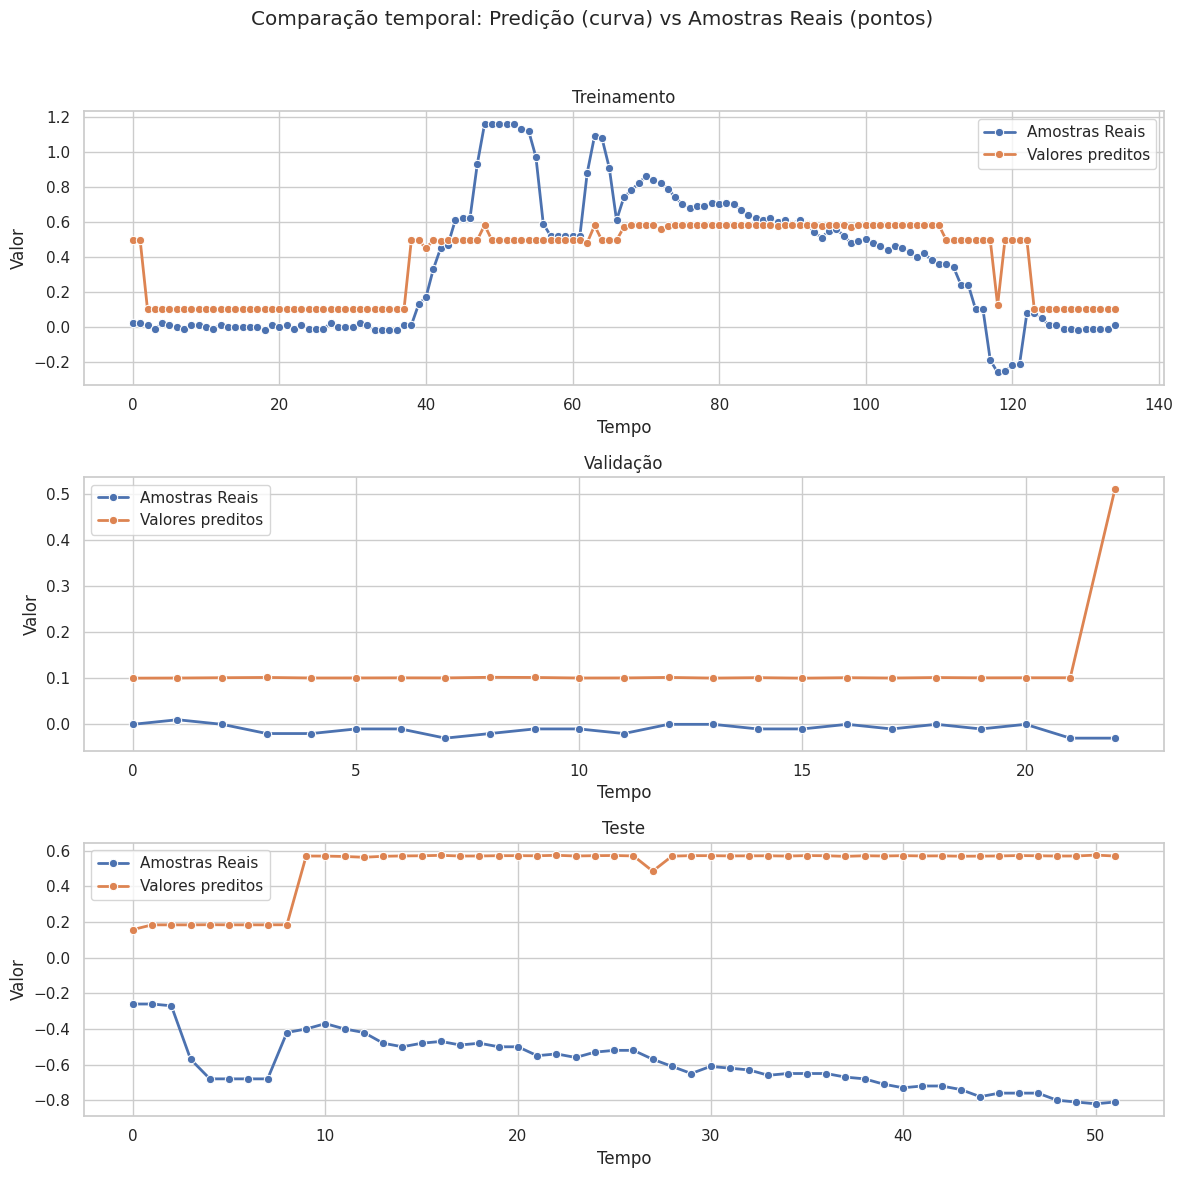

+++++++++++ [2] | 7 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


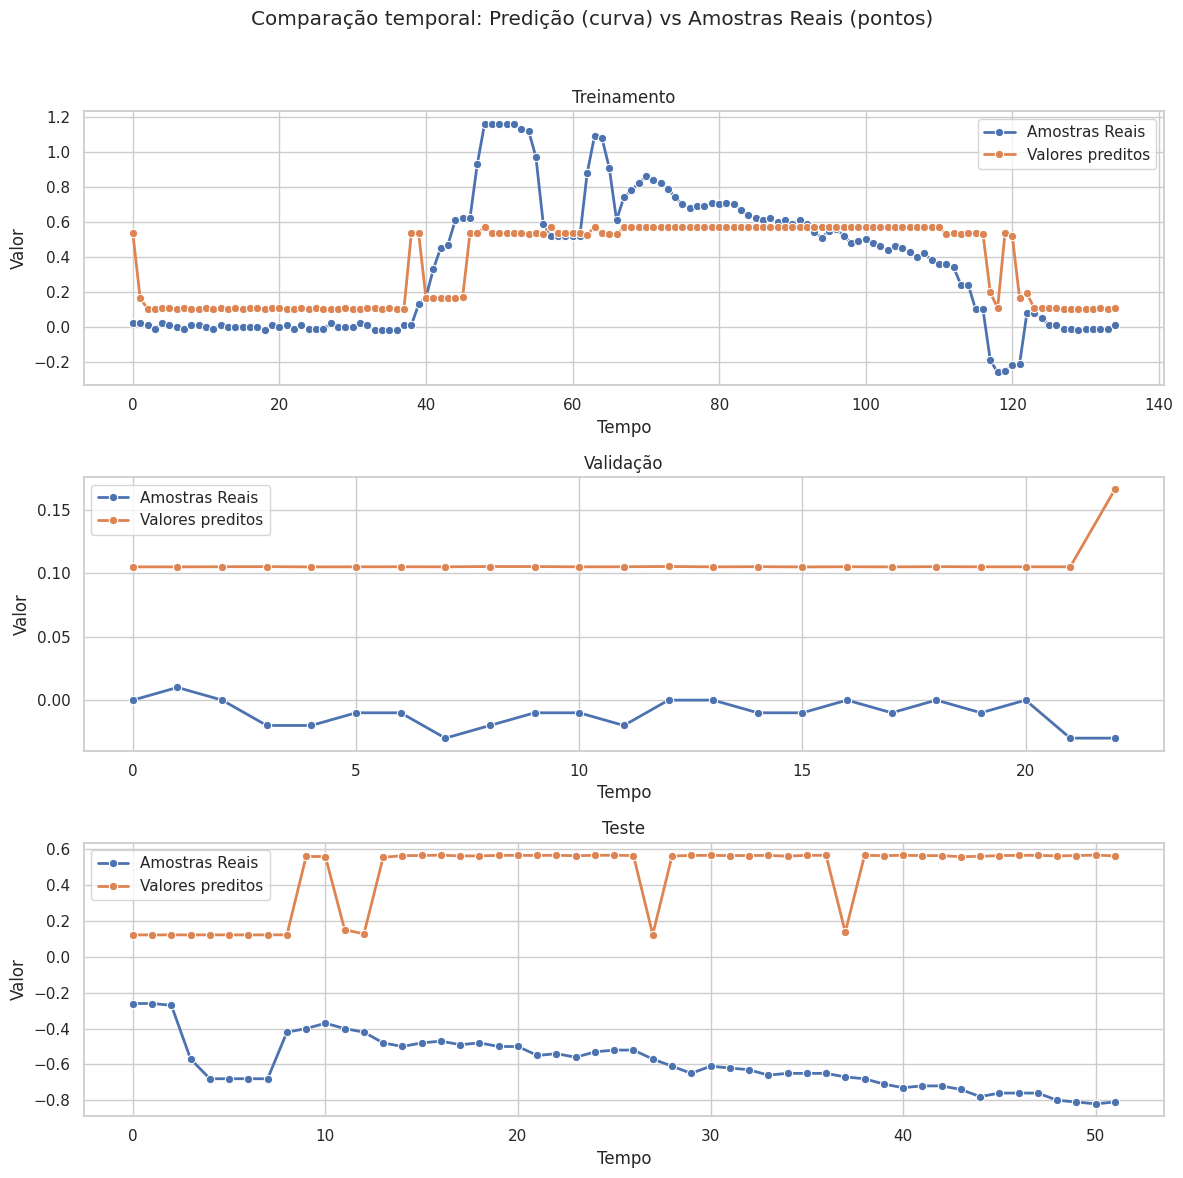

+++++++++++ [2] | 8 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
+++++++++++ [2] | 9 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
+++++++++++ [2] | 10 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_2,0.501165,0.070711,3.769489e+13,0.265916,-26.051358,0.561320,1.261697,0.749213,-115.296539,0.013630,1.422855e+14,0.116749
model_1_0,0.504771,0.070200,4.257583e+13,0.264954,-64.578358,1.360761,2.021356,1.166516,-230.927064,0.027182,1.602985e+14,0.164871
model_2_3,0.509554,0.069522,3.705452e+13,0.263671,-59.336489,1.251991,1.879609,1.118924,-207.904032,0.024484,1.386174e+14,0.156474
model_2_1,0.512476,0.069108,4.166526e+13,0.262884,-26.354182,0.567603,1.265896,0.753395,-134.272502,0.015854,1.570373e+14,0.125914
model_2_0,0.520141,0.068022,4.851514e+13,0.260810,-43.923930,0.932178,1.650276,0.965494,-225.818431,0.026584,1.847522e+14,0.163045
model_2_4,0.544132,0.064621,3.863668e+13,0.254206,-55.565039,1.173733,1.784132,1.083390,-121.546875,0.014363,1.441913e+14,0.119845


DataFrame salvo em ./content/results/metrics_2
Testando combinacao3: Hidden Size=[40], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (135, 10, 2)
Shape Y (batch, output_dim): (135, 1)
Shape h0 (batch, units): (135, 40)
Shape X (batch, time_steps, features): (23, 10, 2)
Shape Y (batch, output_dim): (23, 1)
Shape h0 (batch, units): (23, 40)
Shape X (batch, time_steps, features): (52, 10, 2)
Shape Y (batch, output_dim): (52, 1)
Shape h0 (batch, units): (52, 40)
+++++++++++ [3] | 1 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


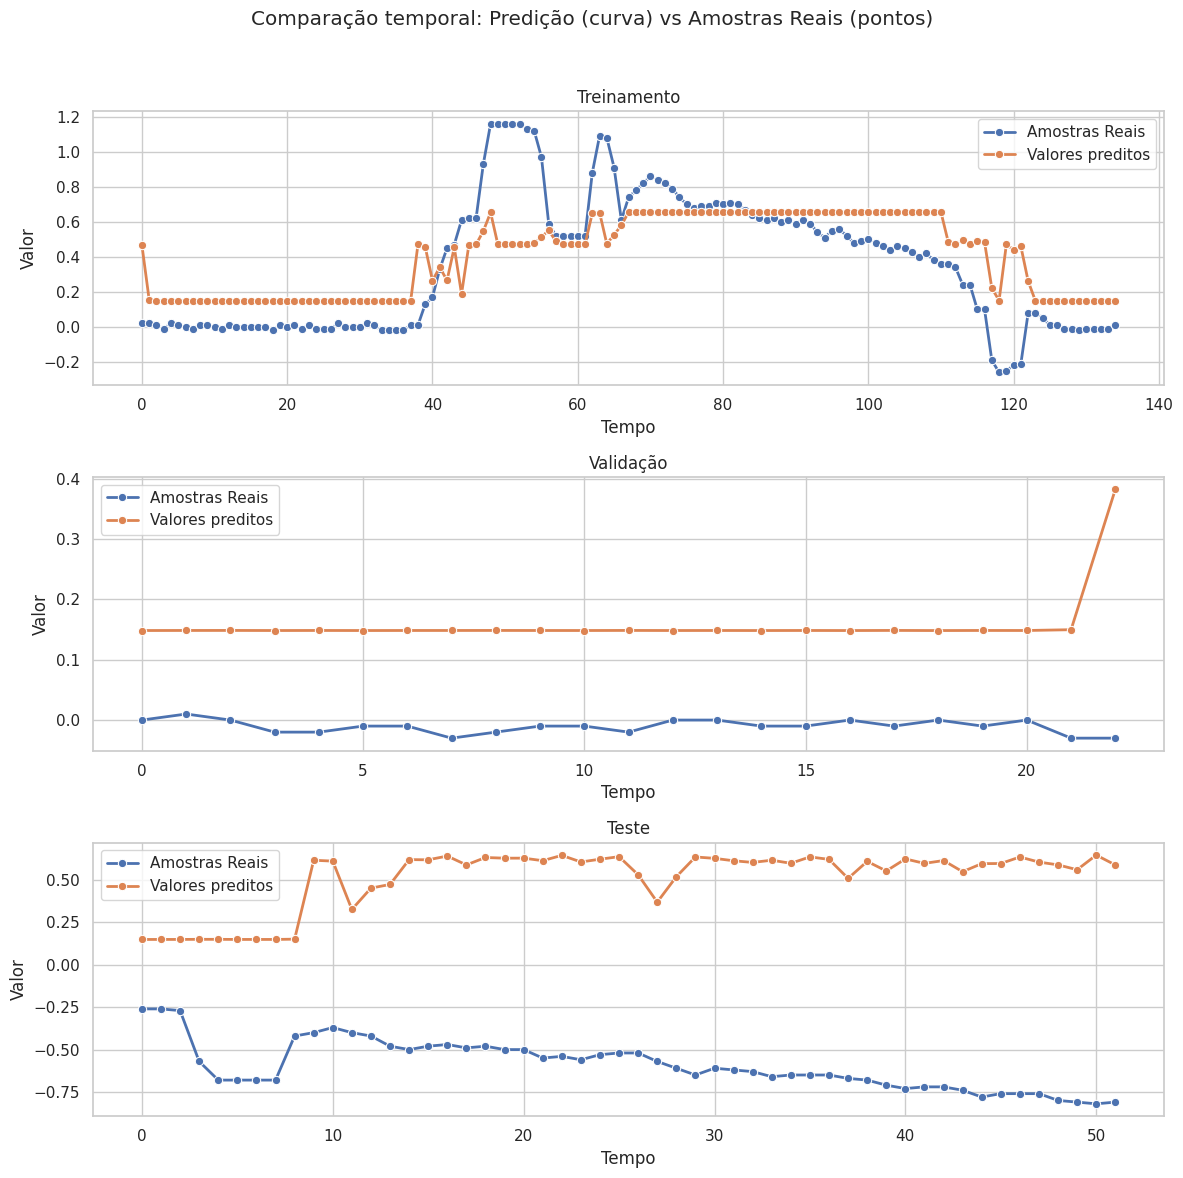

+++++++++++ [3] | 2 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
+++++++++++ [3] | 3 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
+++++++++++ [3] | 4 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
+++++++++++ [3] | 5 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
+++++++++++ [3] | 6 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


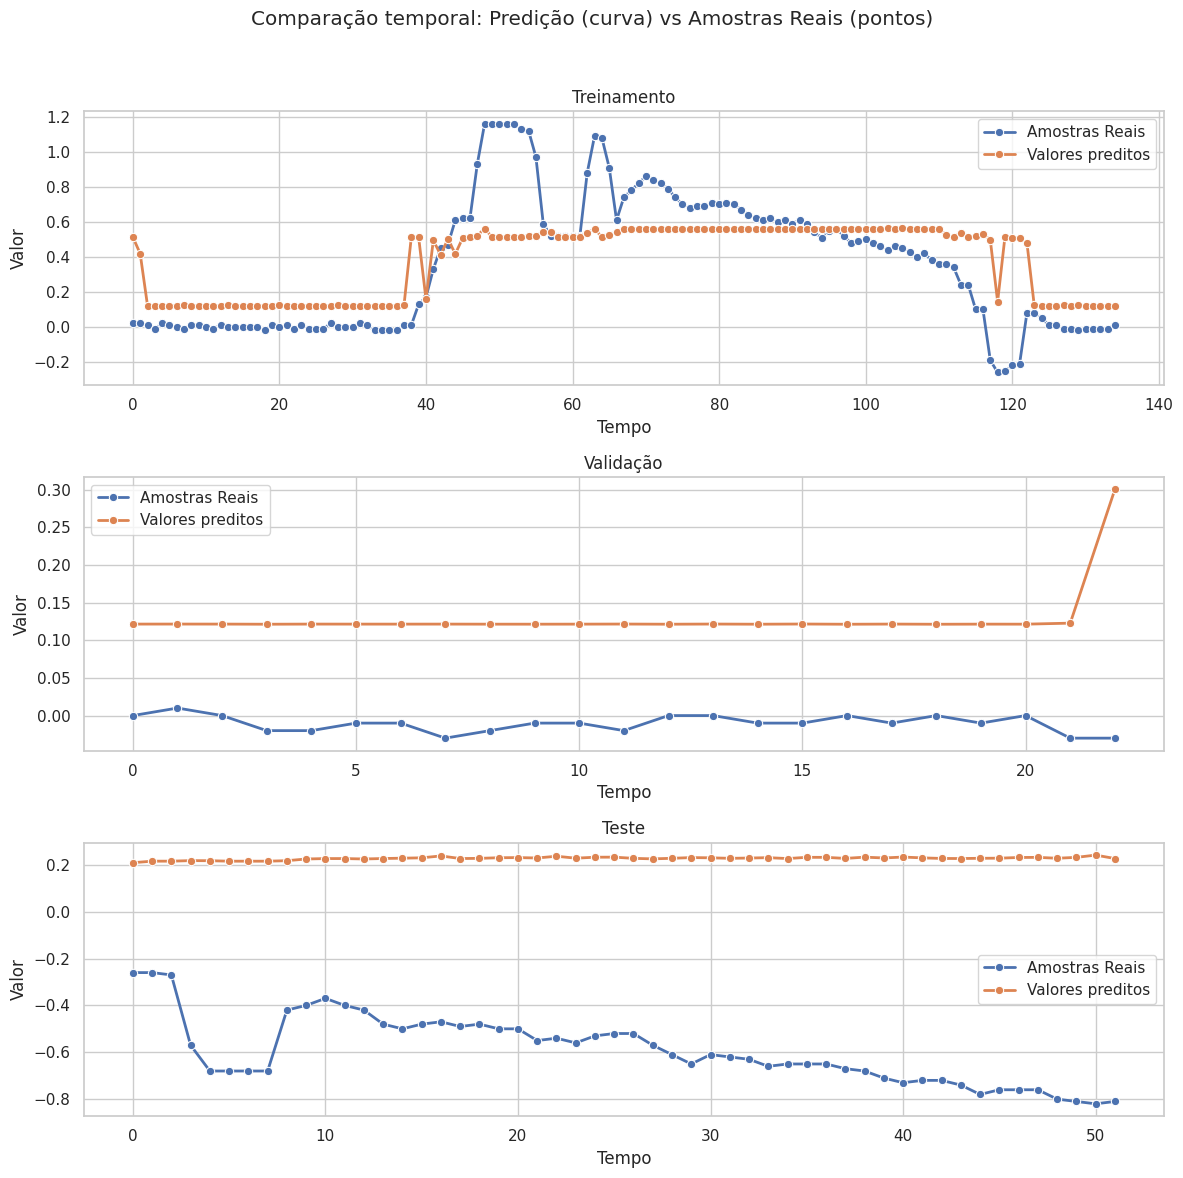

+++++++++++ [3] | 7 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
+++++++++++ [3] | 8 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
+++++++++++ [3] | 9 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


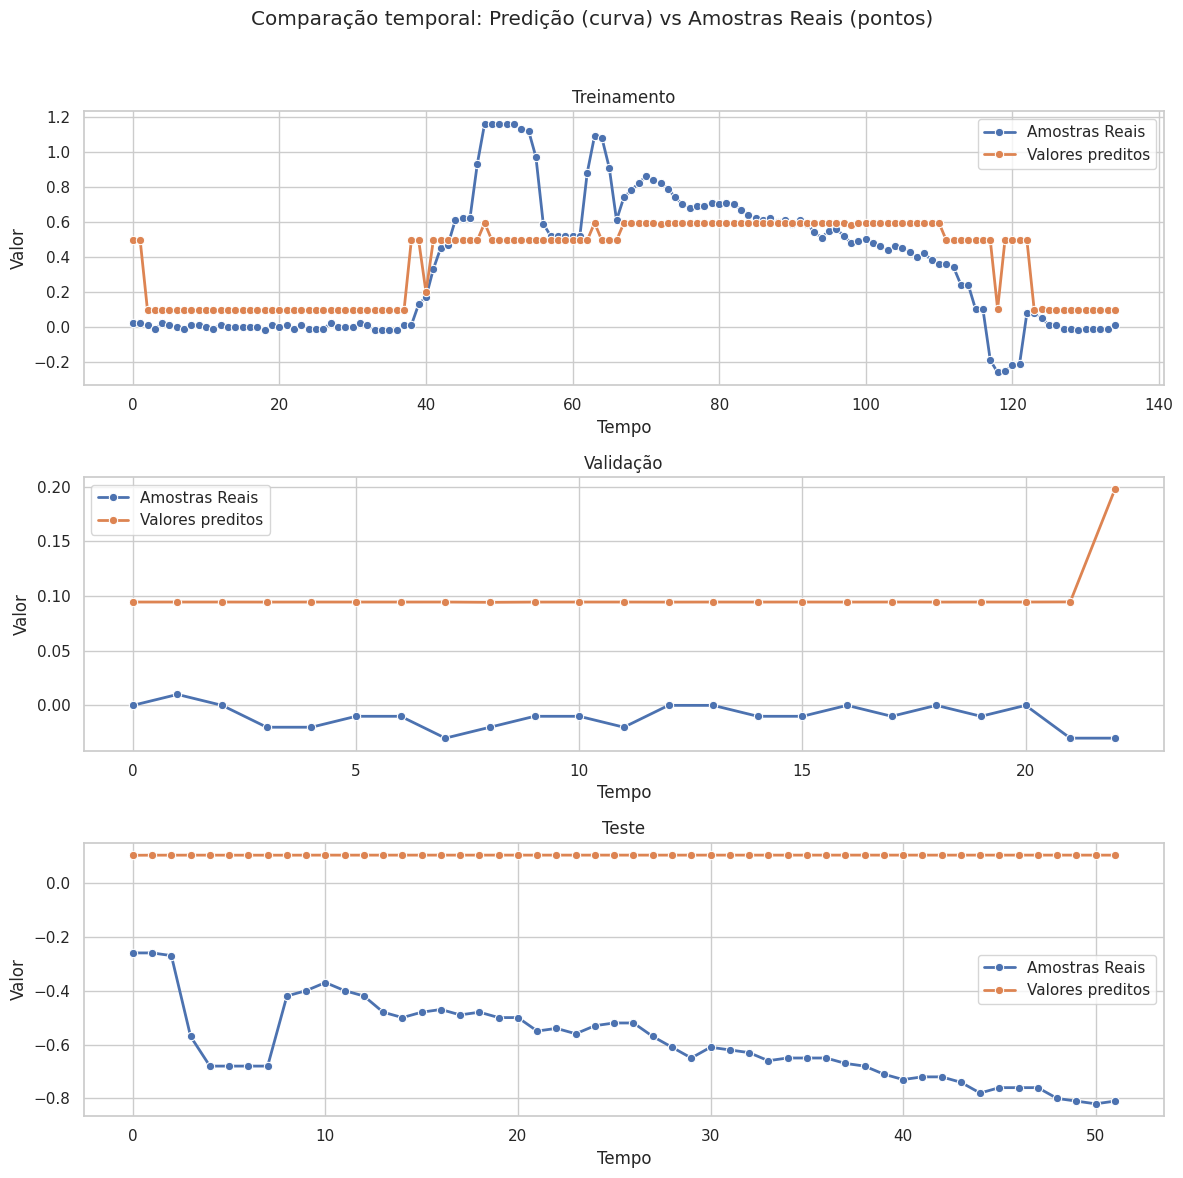

+++++++++++ [3] | 10 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_2,0.501165,0.070711,3.769489e+13,0.265916,-26.051358,0.561320,1.261697,0.749213,-115.296539,0.013630,1.422855e+14,0.116749
model_3_1,0.504231,0.070277,4.485214e+13,0.265098,-32.366642,0.692363,1.413308,0.832083,-180.741021,0.021300,1.665283e+14,0.145947
model_1_0,0.504771,0.070200,4.257583e+13,0.264954,-64.578358,1.360761,2.021356,1.166516,-230.927064,0.027182,1.602985e+14,0.164871
model_2_3,0.509554,0.069522,3.705452e+13,0.263671,-59.336489,1.251991,1.879609,1.118924,-207.904032,0.024484,1.386174e+14,0.156474
model_2_1,0.512476,0.069108,4.166526e+13,0.262884,-26.354182,0.567603,1.265896,0.753395,-134.272502,0.015854,1.570373e+14,0.125914
model_2_0,0.520141,0.068022,4.851514e+13,0.260810,-43.923930,0.932178,1.650276,0.965494,-225.818431,0.026584,1.847522e+14,0.163045
model_3_2,0.521057,0.067892,3.469664e+13,0.260560,-23.266037,0.503524,1.188019,0.709594,-107.473619,0.012713,1.295742e+14,0.112754
model_3_0,0.523981,0.067477,5.450456e+13,0.259764,-61.007824,1.286672,1.888114,1.134315,-267.014476,0.031412,2.035253e+14,0.177234
model_2_4,0.544132,0.064621,3.863668e+13,0.254206,-55.565039,1.173733,1.784132,1.083390,-121.546875,0.014363,1.441913e+14,0.119845


DataFrame salvo em ./content/results/metrics_3
Testando combinacao4: Hidden Size=[45], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (135, 10, 2)
Shape Y (batch, output_dim): (135, 1)
Shape h0 (batch, units): (135, 45)
Shape X (batch, time_steps, features): (23, 10, 2)
Shape Y (batch, output_dim): (23, 1)
Shape h0 (batch, units): (23, 45)
Shape X (batch, time_steps, features): (52, 10, 2)
Shape Y (batch, output_dim): (52, 1)
Shape h0 (batch, units): (52, 45)
+++++++++++ [4] | 1 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
+++++++++++ [4] | 2 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
+++++++++++ [4] | 3 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


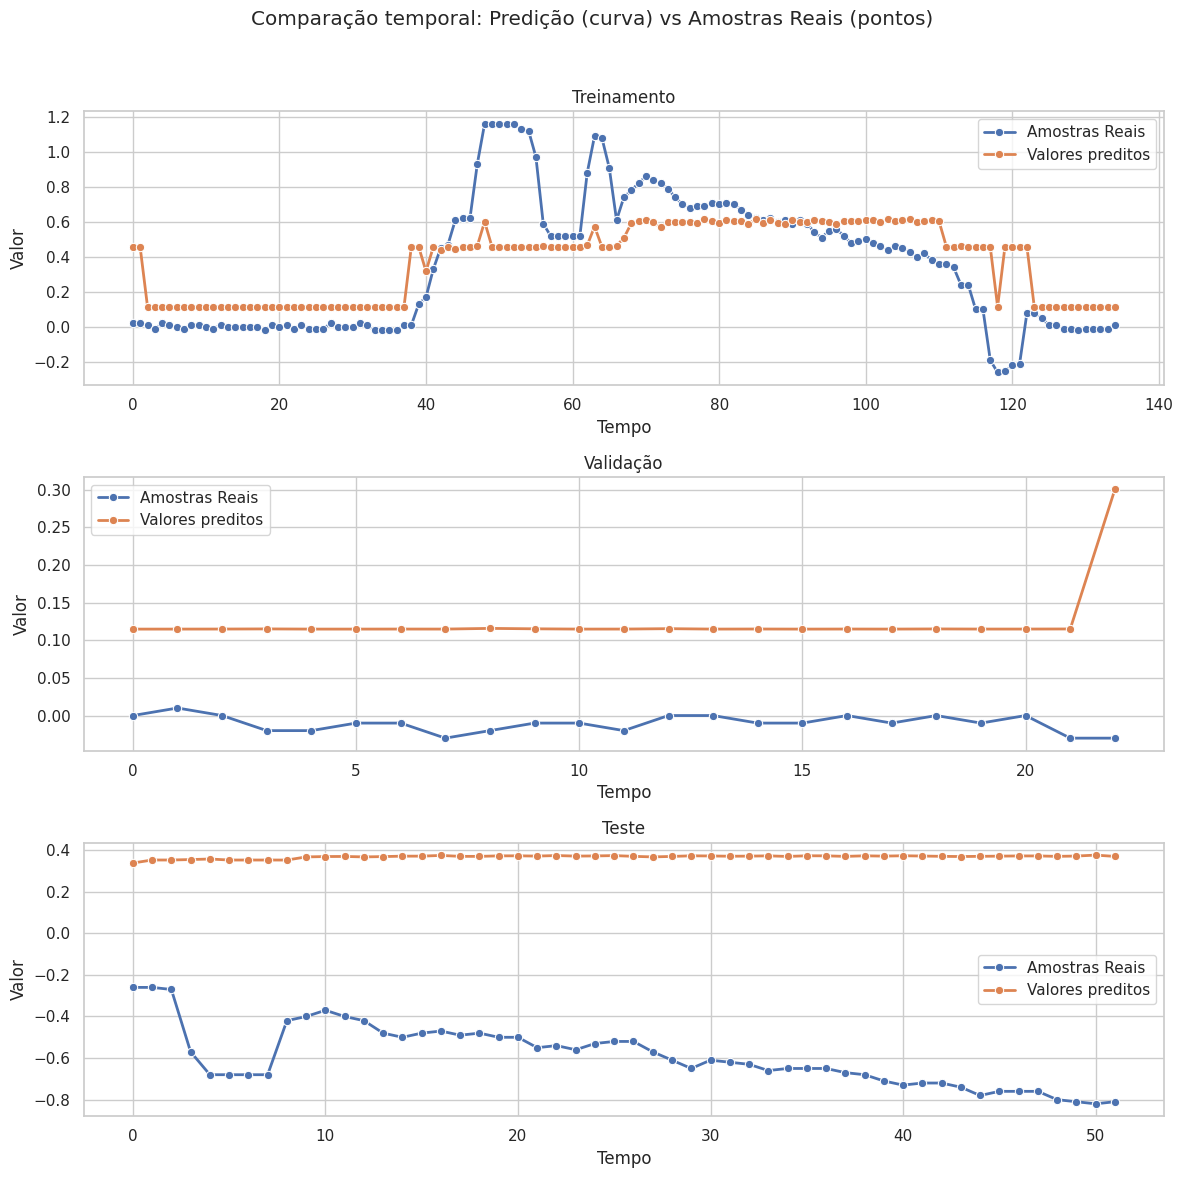

+++++++++++ [4] | 4 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
+++++++++++ [4] | 5 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


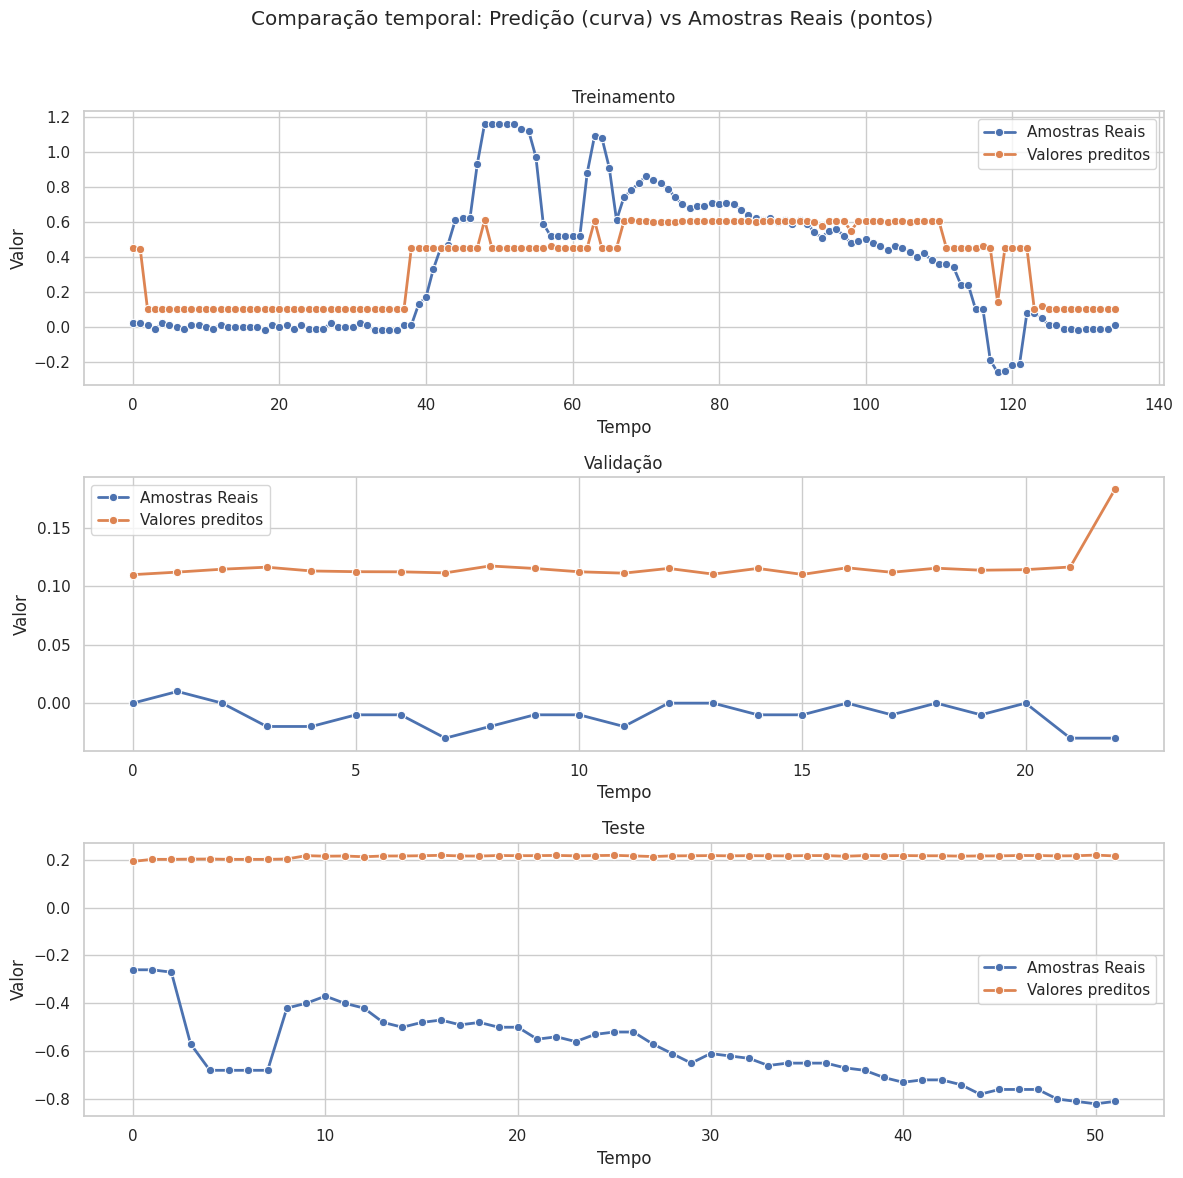

+++++++++++ [4] | 6 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
+++++++++++ [4] | 7 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
+++++++++++ [4] | 8 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
+++++++++++ [4] | 9 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
+++++++++++ [4] | 10 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


,r2_training,mse_training,mape_training,rmse_training,r2_test,mse_test,mape_test,rmse_test,r2_val,mse_val,mape_val,rmse_val
model_2_2,0.501165,0.070711,3.769489e+13,0.265916,-26.051358,0.561320,1.261697,0.749213,-115.296539,0.013630,1.422855e+14,0.116749
model_4_0,0.502548,0.070515,4.242046e+13,0.265547,-44.455787,0.943214,1.670114,0.971192,-166.610644,0.019644,1.574512e+14,0.140158
model_3_1,0.504231,0.070277,4.485214e+13,0.265098,-32.366642,0.692363,1.413308,0.832083,-180.741021,0.021300,1.665283e+14,0.145947
model_1_0,0.504771,0.070200,4.257583e+13,0.264954,-64.578358,1.360761,2.021356,1.166516,-230.927064,0.027182,1.602985e+14,0.164871
model_2_3,0.509554,0.069522,3.705452e+13,0.263671,-59.336489,1.251991,1.879609,1.118924,-207.904032,0.024484,1.386174e+14,0.156474
model_4_1,0.509759,0.069493,3.757361e+13,0.263616,-31.307362,0.670383,1.388666,0.818769,-140.747405,0.016613,1.560462e+14,0.128892
model_2_1,0.512476,0.069108,4.166526e+13,0.262884,-26.354182,0.567603,1.265896,0.753395,-134.272502,0.015854,1.570373e+14,0.125914
model_2_0,0.520141,0.068022,4.851514e+13,0.260810,-43.923930,0.932178,1.650276,0.965494,-225.818431,0.026584,1.847522e+14,0.163045
model_3_2,0.521057,0.067892,3.469664e+13,0.260560,-23.266037,0.503524,1.188019,0.709594,-107.473619,0.012713,1.295742e+14,0.112754
model_3_0,0.523981,0.067477,5.450456e+13,0.259764,-61.007824,1.286672,1.888114,1.134315,-267.014476,0.031412,2.035253e+14,0.177234


DataFrame salvo em ./content/results/metrics_4
Testando combinacao5: Hidden Size=[50], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (135, 10, 2)
Shape Y (batch, output_dim): (135, 1)
Shape h0 (batch, units): (135, 50)
Shape X (batch, time_steps, features): (23, 10, 2)
Shape Y (batch, output_dim): (23, 1)
Shape h0 (batch, units): (23, 50)
Shape X (batch, time_steps, features): (52, 10, 2)
Shape Y (batch, output_dim): (52, 1)
Shape h0 (batch, units): (52, 50)
+++++++++++ [5] | 1 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
+++++++++++ [5] | 2 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
+++++++++++ [5] | 3 ++++++++++++++++++
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
+++++++++++ [5] | 4 ++++++++++++++++++
5/5 ━━━━━━

In [17]:
Valuer.Evaluate(hidden_sizes = [[30], [35], [40], [45], [50]],
            regularizers=[0.2],
            learning_rate=[0.01],
            run_times = 10, 
            boundarie = 0.5,
            sort_by = 'r2_training',
) 